In [523]:
%pip install numpy
%pip install pandas
%pip install seaborn
%pip install matplotlib.pyplot

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot
Note: you may need to restart the kernel to use updated packages.


In [524]:
%pip install matplotlib
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.


In [525]:
%pip install pandas_datareader

Note: you may need to restart the kernel to use updated packages.


In [526]:
2+3

5

In [527]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [528]:
%pip install getFamaFrenchFactors
%pip install numpy 
%pip install pandas 
%pip install seaborn 
%pip install matplotlib 
%pip install pandas-datareader 
%pip install scikit-learn 
%pip install plotly 
%pip install ipython 
%pip install random 
%pip install yfinance 
%pip install statsmodels 
%pip install pulp


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement random (from versions: none)
ERROR: No matching distribution found for random
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [529]:

%pip install pyarrow


Note: you may need to restart the kernel to use updated packages.


In [1]:
# GENERAL USE LIBRARY IMPORTS

import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar

from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
import getFamaFrenchFactors as gff
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
yf.pdr_override()

# OPTIMIZATION LIBRARY IMPORTS
import pulp
from pulp import *
from sklearn.preprocessing import LabelEncoder

In [531]:
%pip install setuptools


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas_datareader.data as reader


In [533]:
%pip install --upgrade certifi



Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf

# Your code using yfinance module goes here


In [4]:
import pandas as pd
import requests

# Disable SSL certificate verification
requests.packages.urllib3.disable_warnings()

# Fetch HTML content
response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', verify=False)
html_content = response.content

# Read HTML content into pandas DataFrame
list_of_dfs = pd.read_html(html_content)
wikitable_sp_500 = list_of_dfs[0]
sp500_symbols = wikitable_sp_500['Symbol']


In [5]:
#Converting SP_500 tickers into list 
tickers = sp500_symbols.to_list()
#Remove some tickers as they create an error for the yfinance api
tickers[65] = 'BRK-B'
tickers[81] = 'BF-B'
tickers.remove('BF-B')
tickers.remove('BRK-B')

In [6]:
#Start Date for In Sample Historical Data
start = '2020-05-01'
#End Date for In Sample Historical Data
end   = '2023-06-01'
#Monthly Returns for Stocks in the List
monthly_data = yf.download(tickers,start=start,end=end,interval='1mo')
#Reformat Date Index 
monthly_data.index = pd.to_datetime(monthly_data.index)
monthly_data = monthly_data.tz_localize(None)
#Turn Adj Close prices into pct returns
monthly_data = monthly_data['Adj Close'].pct_change()
#Drop First row NaN values
monthly_data = monthly_data.drop(monthly_data.index[0])
#Drop if stock doesnt have data starting from the first index date
monthly_data = monthly_data.dropna(axis=1)
#Assign equal weight as base weights
base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])
#Getting SP_500 data
spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())
#Dropping First Row(NaN) and formatting index to match monthly_data 
spy = spy.drop(spy.index[0]).tz_localize(None)
#Adding SP_500 data to monthly_data
monthly_data['SP_500'] = spy['Adj Close']

[*********************100%%**********************]  501 of 501 completed

6 Failed downloads:
['VLTO', 'SOLV', 'GEV']: Exception("%ticker%: Data doesn't exist for startDate = 1588305600, endDate = 1685592000")
['BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2020-05-01 -> 2023-06-01)')
['KVUE']: IndexError('index 0 is out of bounds for axis 0 with size 0')
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')
/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ipykernel_99697/3085826990.py:11: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_data = monthly_data['Adj Close'].pct_change()
[*********************100%%**********************]  1 of 1 completed


In [7]:
#Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
tickers = list(monthly_data.columns[:-1])
tick_index = tickers + ['SP_500']

In [8]:
import numpy as np
import matplotlib.pyplot as plt

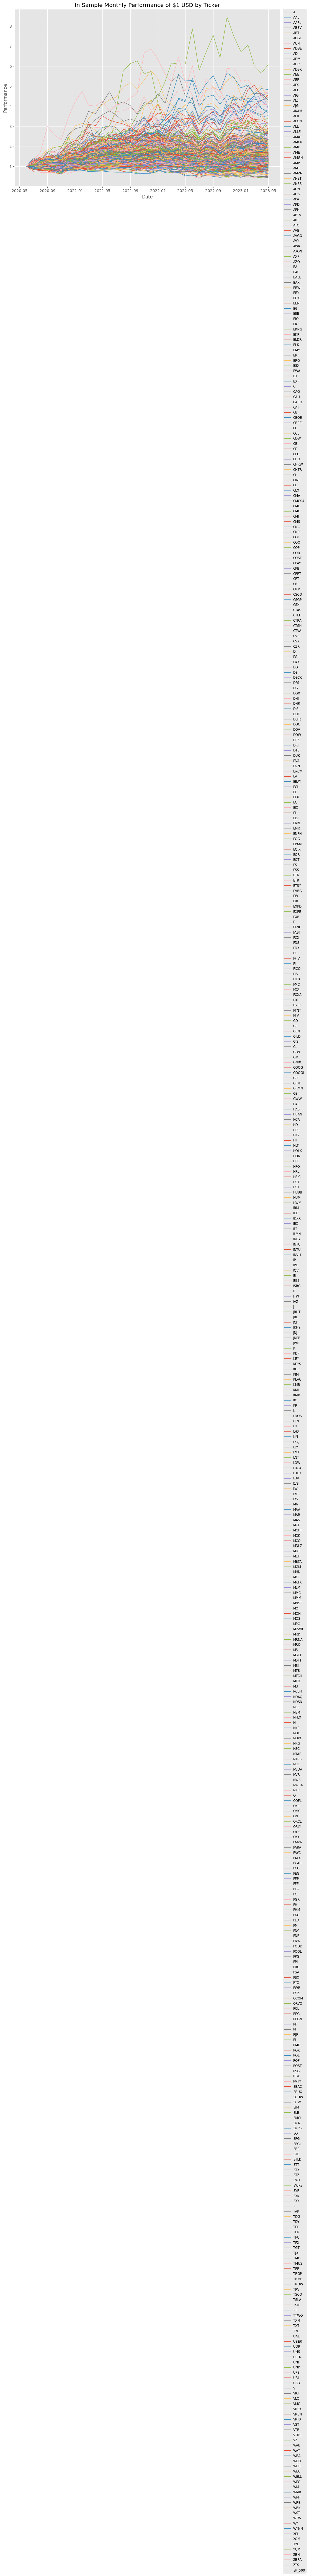

In [9]:
# IN SAMPLE HISTORICAL MONTHLY PERFORMANCE

init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

performance = pd.DataFrame(np.ones((len(monthly_data),len(monthly_data.columns))), index = monthly_data.index, columns = monthly_data.columns)
for j in range(1,len(monthly_data.index)):
    performance.iloc[j] = performance.iloc[j-1]*(monthly_data.iloc[j-1][monthly_data.columns]+init)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes
for i in range(0,len(monthly_data.columns)):
        axes.plot(performance.index, performance.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('In Sample Monthly Performance of $1 USD by Ticker')
axes.legend(tick_index, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.show()

In [10]:
import getFamaFrenchFactors as gff

In [11]:
# Fama French Monthly Returns Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
# Keeping Only the Dates in the monthly_data
ff3_monthly = ff3_monthly.loc[monthly_data.index]

In [12]:
# Correlation of Factor Returns
ff3_monthly.corr()

,Mkt-RF,SMB,HML,RF
Mkt-RF,1.000000,0.154466,-0.188295,-0.059297
SMB,0.154466,1.000000,-0.129832,-0.091568
HML,-0.188295,-0.129832,1.000000,-0.318977
RF,-0.059297,-0.091568,-0.318977,1.000000


In [13]:
# Stats for Factor Returns
ff3_monthly.describe()

,Mkt-RF,SMB,HML,RF
count,36.000000,36.000000,36.000000,36.000000
mean,0.009814,0.000886,0.006961,0.000908
std,0.052935,0.031127,0.049476,0.001366
min,-0.094600,-0.059400,-0.088500,0.000000
25%,-0.023625,-0.019550,-0.019075,0.000000
50%,0.018650,-0.002350,-0.000950,0.000100
75%,0.046075,0.020625,0.035075,0.001900
max,0.124700,0.073600,0.127500,0.003600


In [14]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

In [15]:
# Create an empty DataFrame to store the Stock Betas
stock_betas = pd.DataFrame()

# Iterate over the tickers list
for col in monthly_data.columns:
    # Set the dependent variable (Return of stock i)
    y = monthly_data[col]
    
    # Set the independent variables (Fama French 3 Factors)
    X = ff3_monthly[['Mkt-RF','SMB','HML']]
    
    # Fit the multiple linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Store the results in the DataFrame
    stock_betas[col] = [model.intercept_] + list(model.coef_)
stock_betas = stock_betas.T
stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ipykernel_99697/3614759814.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stock_betas[col] = [model.intercept_] + list(model.coef_)
/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ipykernel_99697/3614759814.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  stock_betas[col] = [model.intercept_] + list(model.coef_)
/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ipykernel_99697/3614759814.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

In [16]:
# Check the Betas for an individual stock - Put the ticker of the desired stock in the ' '.
stock_betas.loc['AAPL']

Intercept    0.018996
Mkt-RF       1.269937
SMB         -0.349982
HML         -0.584071
Name: AAPL, dtype: float64

In [17]:
# Stats for Stock Betas
stock_betas.describe()

,Intercept,Mkt-RF,SMB,HML
count,493.000000,493.000000,493.000000,493.000000
mean,0.002468,1.003941,0.015925,0.269666
std,0.011892,0.376924,0.611077,0.523191
min,-0.034720,0.013693,-1.204090,-1.430609
25%,-0.003593,0.752648,-0.408388,-0.059685
50%,0.002020,0.978461,-0.068498,0.220573
75%,0.008164,1.229636,0.361431,0.598626
max,0.076225,2.441397,2.549699,2.171452


In [18]:
#Stock Prices on the Day of Optimization(Rebalancing)
stock_price = pd.DataFrame(yf.download(tickers,start=start,end=end,interval='1d')['Adj Close'])
stock_price = stock_price[-1:]
stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)

s_price = {}
s_keys = list(tickers)
s_values =  list(stock_price.iloc[0])
for key,value in zip(s_keys,s_values):
    s_price[key] = value

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[                       0%%                      ]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[                       0%%                      ]  2 of 492 completed/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += 

In [19]:
import random

In [20]:
#Transaction Costs
random.seed(1)
t_cost = {}
keys       = list(tickers)
#values     = [.15 for i in range(len(keys))]
values = list(random.uniform(.01,.02) for i in range(len(tickers)))
for key,value in zip(keys,values):
    t_cost[key] = value

In [21]:
#SP_500 Factor Betas
stock_betas.iloc[-1,1:]

Mkt-RF    0.985868
SMB      -0.187391
HML       0.008352
Name: SP_500, dtype: float64

In [22]:
# TARGET FACTOR BETAS 
mkt_opt = 1.21                          # TARGET MKT BETA - EXPOSURE OF THE NEW PORTFOLIO TO MARKET FACTOR 
smb_opt = .30                           # TARGET SMB BETA - EXPOSURE OF THE NEW PORTFOLIO TO SIZE FACTOR 
hml_opt = 0.8                           # TARGET HML BETA - EXPOSURE OF THE NEW PORTFOLIO TO VALUE FACTOR 
B = 1000000                             # BUDGET
q = 50                                # NUMBER OF STOCKS IN THE NEW PORTFOLIO
base_weights = base_w.T*0               # ONLY HAVE THIS LINE OF CODE WHEN YOU ARE CONSTRUCTING THE PORTFOLIO FROM SCRATCH                                      


In [23]:
from pulp import LpProblem, LpMaximize, LpVariable, LpMinimize, LpBinary, lpSum

In [24]:
# OPTIMIZATION MODEL

index = LpProblem('Index', LpMinimize)

# Decision Variables

wei = LpVariable.dicts('Weight',tickers,lowBound=0)                           # Weights for stock i in the optimal portfolio
aux = LpVariable.dicts('Y',tickers,lowBound=0)                                
err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)               # Error term for portfolio
binary = LpVariable.dicts('bin',tickers,cat=LpBinary)                         # Used if we want to limit the # of stocks we want to have in optimal portfolio
tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Total Transaction cost for stock i in the optimal portfolio
shares = LpVariable.dicts('shares',tickers,lowBound=0)                        # Total Transaction cost for stock i in the optimal portfolio


#Objective Function - Minimize the error term 
index +=  lpSum(err[t] for t in monthly_data.index)

# Constraint: Weights sum to 1 
index += lpSum(wei[i] for i in tickers) == 1

# Constraint: Absolute value of change in weights from base weigths
for i in tickers:
    index += aux[i] >= base_weights[i]  - wei[i]
    index += aux[i] >= wei[i] - base_weights[i]
index += lpSum(aux[i] for i in tickers) <= 1
# Constraint: Error term
for t in monthly_data.index:
    index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) - err[t] <= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
    index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) + err[t] >= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])

# Shares
for i in tickers:
    index += shares[i] == (aux[i]*B/s_price[i])

# Transaction Costs
for i in tickers:
    index += lpSum(aux[i] *B*t_cost[i]/s_price[i]) == tr_cost[i]
index += lpSum(tr_cost[i] for i in tickers) <= 2000
# Limit # of stocks in Optimal Portfolio
for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
    index += wei[i] <= binary[i]
    
index += lpSum(binary[i] for i in tickers) <= q

index.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/b4558f9e32ff405b8f0c942bd83b2bbb-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/b4558f9e32ff405b8f0c942bd83b2bbb-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2541 COLUMNS
At line 45940 RHS
At line 48477 BOUNDS
At line 48970 ENDATA
Problem MODEL has 2536 rows, 2496 columns and 42378 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 1060 rows, 1512 columns (492 integer (492 of which binary)) and 39426 elements
Cbc0038I Initial state - 37 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 2.06702 ite

1

In [558]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [559]:
#Change in number of shares
sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
sharess
sharess.to_excel('shares.xlsx')

In [560]:
#Transaction Costs
tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
tr_cost.sum()

Optimal    355.77661
dtype: float64

In [561]:
#Optimal weights
weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
weii.sum()

Optimal    1.0
dtype: float64

In [562]:
#Change of weights
auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
auxx.sum()

Optimal    1.0
dtype: float64

In [563]:
#Error terms
errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
errr.sum()

Optimal    0.0
dtype: float64

In [564]:
# Check if Binary Values Constraint works
binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
binary_v.sum()

Optimal    38.0
dtype: float64

In [565]:
# Weights in Optimal Portfolio
opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
opt_weights.style.format('{:,.2%}'.format)

,Optimal
Weight_AMAT,0.37%
Weight_APA,5.02%
Weight_BAC,4.33%
Weight_BG,3.42%
Weight_BX,1.18%
Weight_C,2.44%
Weight_CI,0.34%
Weight_COF,1.55%
Weight_CVS,0.05%
Weight_DD,6.45%


In [566]:
opt_weights

,Optimal
Weight_AMAT,0.003724
Weight_APA,0.050190
Weight_BAC,0.043282
Weight_BG,0.034233
Weight_BX,0.011817
Weight_C,0.024442
Weight_CI,0.003403
Weight_COF,0.015457
Weight_CVS,0.000549
Weight_DD,0.064472


In [567]:

weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
for t in monthly_data.columns[:-1]:
    weights.loc[t][0] = base_w.loc[t]
    weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
    weights.loc[t][2] = weights_new.loc[t]
weights

/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ipykernel_11826/774888063.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  weights.loc[t][0] = base_w.loc[t]
/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ipykernel_11826/774888063.py:4:

,PORTFOLIO Weights,Difference,New Weights
Ticker,,,
A,0.002024,-0.002024,0.0
AAL,0.002024,-0.002024,0.0
AAPL,0.002024,-0.002024,0.0
ABBV,0.002024,-0.002024,0.0
ABT,0.002024,-0.002024,0.0
...,...,...,...
YUM,0.002024,-0.002024,0.0
ZBH,0.002024,-0.002024,0.0
ZBRA,0.002024,-0.002024,0.0


In [568]:
columns_to_remove = ['PORTFOLIO Weights', 'Difference']

# Specify the column to filter non-zero values
column_to_filter = 'New Weights'

# Create a new DataFrame with selected columns and rows where New Weights is not equal to 0
opt_portf_weights = weights.drop(columns=columns_to_remove)[weights[column_to_filter] != 0]


In [569]:
# CHECK PORTFOLIO BETAS

port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
for j in port_returns.index:
    port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
    port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)

# Create an empty DataFrame to store the Portfolio Beta
port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])

port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]

# Set the independent variables (Fama French 3 Factors)
X = port_returns[['Mkt-RF','SMB','HML']]
# Set the dependent variable (Return of Portfolio)
Y = port_returns['SP_500']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
port_betas['SP_500'] = regr.coef_

# Set the dependent variable (Return of Portfolio)
Y = port_returns['Optimization']
# Fit the multiple linear regression model
regr = LinearRegression()
regr.fit(X,Y)
port_betas['Optimization'] = regr.coef_

# Abs Difference between Target Betas & Optimal Portfolio Betas
port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
port_betas

/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ipykernel_11826/1317841671.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ip

,SP_500,Target,Optimization,Abs. Diff
Mkt-RF,0.985868,1.21,1.207228,0.0028
SMB,-0.187391,0.30,0.294688,0.0053
HML,0.008352,0.80,0.790202,0.0098


In [570]:
fama_stocks_future_df=opt_weights
i=0
fama_stocks_future_beta_df=pd.DataFrame()
for index, row in fama_stocks_future_df.iterrows():
    row_name = index
    fama_stocks_future = index.replace('Weight_', '')
    fama_stocks_future_beta=stock_betas.loc[fama_stocks_future]
    fama_stocks_future_beta_df[fama_stocks_future]=fama_stocks_future_beta
fama_stocks_future_beta_df.drop("Intercept", inplace=True)
fama_stocks_future_beta_df
for column in fama_stocks_future_beta_df.columns:
    max_abs_row = fama_stocks_future_beta_df[column].abs().idxmax()
    if max_abs_row == "HML":
        max_abs_row="Value stock"
    elif max_abs_row=="SMB":
        max_abs_row="Small Cap stock"
    else:
        max_abs_row="Market Risk stock"
    fama_stocks_future_beta_df.at['Stock Type', column] = max_abs_row

fama_stocks_future_beta_df.transpose() 

/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ipykernel_11826/1561199300.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Market Risk stock' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  fama_stocks_future_beta_df.at['Stock Type', column] = max_abs_row
/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ipykernel_11826/1561199300.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Market Risk stock' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  fama_stocks_future_beta_df.at['Stock Type', column] = max_abs_row
/var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ipykernel_11826/1561199300.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Market Risk 

,Mkt-RF,SMB,HML,Stock Type
AMAT,1.702109,0.875127,0.370098,Market Risk stock
APA,1.964178,0.384542,1.872521,Market Risk stock
BAC,1.387151,0.395463,1.064499,Market Risk stock
BG,0.857497,0.137623,1.01466,Value stock
BX,1.610453,-0.052743,0.366433,Market Risk stock
C,1.419489,0.688799,1.066153,Market Risk stock
CI,0.682531,0.322072,0.956127,Value stock
COF,1.128148,0.950934,0.730607,Market Risk stock
CVS,0.646712,0.143531,0.682132,Value stock
DD,1.091138,0.264092,0.504341,Market Risk stock


In [571]:
Multiscore_df=fama_stocks_future_beta_df.transpose() 
Multiscore_df["Multi Factor Score1"]=Multiscore_df.apply(lambda x: x['Mkt-RF']/mkt_opt + x['SMB']/smb_opt + x['HML']/hml_opt, axis=1)
Multiscore_df["Multi Factor Score2"]=Multiscore_df.apply(lambda x: x['Mkt-RF'] + x['SMB'] + x['HML'], axis=1)
Multiscore_df["Multi Factor Score3"]=Multiscore_df.apply(lambda x: x['Mkt-RF']-mkt_opt + x['SMB']-smb_opt + x['HML']-hml_opt, axis=1)
Multiscore_df["Multi Factor Score4"] = Multiscore_df.apply(lambda x: x['Mkt-RF'] - mkt_opt + x['SMB'] + x['HML'] if x["Stock Type"] == "Market Risk stock" else (x['Mkt-RF'] - smb_opt + x['SMB'] + x['HML'] if x["Stock Type"] == "Small Cap stock" else x['Mkt-RF'] - hml_opt + x['SMB'] + x['HML']), axis=1)
Multiscore_df


,Mkt-RF,SMB,HML,Stock Type,Multi Factor Score1,Multi Factor Score2,Multi Factor Score3,Multi Factor Score4
AMAT,1.702109,0.875127,0.370098,Market Risk stock,4.786414,2.947334,0.637334,1.737334
APA,1.964178,0.384542,1.872521,Market Risk stock,5.245746,4.221241,1.911241,3.011241
BAC,1.387151,0.395463,1.064499,Market Risk stock,3.795239,2.847113,0.537113,1.637113
BG,0.857497,0.137623,1.01466,Value stock,2.435745,2.009780,-0.300220,1.209780
BX,1.610453,-0.052743,0.366433,Market Risk stock,1.613184,1.924143,-0.385857,0.714143
C,1.419489,0.688799,1.066153,Market Risk stock,4.801818,3.174440,0.864440,1.964440
CI,0.682531,0.322072,0.956127,Value stock,2.832807,1.960730,-0.349270,1.160730
COF,1.128148,0.950934,0.730607,Market Risk stock,5.015391,2.809688,0.499688,1.599688
CVS,0.646712,0.143531,0.682132,Value stock,1.865576,1.472376,-0.837624,0.672376
DD,1.091138,0.264092,0.504341,Market Risk stock,2.412500,1.859571,-0.450429,0.649571


In [572]:
sp500_future = pd.read_csv('ES=F1.csv',index_col='Date')
sp500_future.drop(columns=["Open", "High", "Low", "Close", "Volume"], inplace=True)

In [573]:
sp500_futures

,Futures Pct Change
Date,
2019-03-01,0.019032
2019-04-01,0.039027
2019-05-01,-0.066474
2019-06-01,0.069664
2019-07-01,0.012907
2019-08-01,-0.019281
2019-10-01,0.037952
2019-11-01,0.035576
2020-01-01,0.025527


In [574]:
sp500_futures = sp500_future.pct_change().dropna()
sp500_futures.rename(columns={'Adj Close':'Futures Pct Change'},inplace=True)
#sp500_futures.drop(sp500_futures.index[-1],inplace=True)
#sp500_futures.drop(sp500_futures.index[:13],inplace=True)

is_sp500_futures = sp500_futures.iloc[:-12]
is_sp500_futures


,Futures Pct Change
Date,
2019-03-01,0.019032
2019-04-01,0.039027
2019-05-01,-0.066474
2019-06-01,0.069664
2019-07-01,0.012907
2019-08-01,-0.019281
2019-10-01,0.037952
2019-11-01,0.035576
2020-01-01,0.025527


In [575]:
os_sp500_futures = sp500_futures.iloc[-12:]
os_sp500_futures

,Futures Pct Change
Date,
2022-12-01,-0.053966
2023-02-01,0.029656
2023-03-01,0.040812
2023-04-01,0.012265
2023-05-01,0.000477
2023-06-01,0.071054
2023-07-01,0.028129
2023-08-01,-0.021346
2023-09-01,-0.042183


In [576]:
# Fama French Monthly Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
ff3_monthly = ff3_monthly.loc[is_sp500_futures.index]
ff3_monthly

,Mkt-RF,SMB,HML,RF
Date,,,,
2019-03-01,0.0110,-0.0305,-0.0417,0.0019
2019-04-01,0.0397,-0.0174,0.0215,0.0021
2019-05-01,-0.0694,-0.0132,-0.0237,0.0021
2019-06-01,0.0693,0.0029,-0.0071,0.0018
2019-07-01,0.0119,-0.0193,0.0048,0.0019
2019-08-01,-0.0258,-0.0238,-0.0478,0.0016
2019-10-01,0.0206,0.0029,-0.0191,0.0016
2019-11-01,0.0387,0.0077,-0.0202,0.0012
2020-01-01,-0.0011,-0.0311,-0.0625,0.0013


In [577]:
# Regression Analysis on Market Factor Vs SP 500 Futures Data 
y = ff3_monthly['Mkt-RF']
X = is_sp500_futures['Futures Pct Change'].values.reshape(-1,1)

model = LinearRegression()
model.fit(X, y)
MKT_hedge=model.coef_
print('Minimum variance Hedge ratio for Mkt-RF Factor:',model.coef_ )


Minimum variance Hedge ratio for Mkt-RF Factor: [0.84094485]


In [578]:
#future price function

def get_last_future_price(symbol):
    future = yf.Ticker(symbol)
    data = future.history(period="1d")
    last_price = data['Close'].iloc[-1]
    return last_price


In [579]:
prev_N=0
compensate_mkt=0.98/MKT_hedge
compensate_mkt

array([1.16535585])

In [580]:
#Optimal Number of Contracts
last_price_mkt= get_last_future_price("ES=F")
size_of_position = B
size_of_one_futures_contract = 50*last_price_mkt
current_beta = MKT_hedge
target_beta =0

if current_beta > target_beta:
    N = -(current_beta-target_beta) * (size_of_position)/(size_of_one_futures_contract)
   
else:
    N = (target_beta-current_beta) * (size_of_position)/(size_of_one_futures_contract)
N_mkt=N
print("The number of Contracts to purchase to hedge the market beta :",N_mkt) 

The number of Contracts to purchase to hedge the market beta : [-3.29782293]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')


In [581]:
return_hedge_mkt=abs(N_mkt) * (sp500_future.loc['2023-02-01']['Adj Close'] - sp500_future.loc['2024-01-01']['Adj Close'])
return_hedge_mkt_pct=return_hedge_mkt[0]/B
print(return_hedge_mkt)

[-2951.55152261]


In [582]:
russell_2000_future = pd.read_csv('^RUT.csv',index_col='Date')
russell_2000_future.drop(columns=["Open", "High", "Low", "Close", "Volume"], inplace=True)

In [583]:
russell_2000_futures = russell_2000_future.pct_change().dropna()
russell_2000_futures.rename(columns={'Adj Close':'Futures Pct Change'},inplace=True)
is_russell_2000_futures = russell_2000_futures.iloc[:-12]
is_russell_2000_futures

,Futures Pct Change
Date,
2019-03-01,-0.022729
2019-04-01,0.033428
2019-05-01,-0.079009
2019-06-01,0.068973
2019-07-01,0.005132
2019-08-01,-0.050660
2019-09-01,0.019086
2019-10-01,0.025654
2019-11-01,0.039713


In [584]:
os_russell_2000_futures = russell_2000_futures.iloc[-12:]
os_russell_2000_futures

,Futures Pct Change
Date,
2023-02-01,-0.018091
2023-03-01,-0.049821
2023-04-01,-0.018580
2023-05-01,-0.010933
2023-06-01,0.079490
2023-07-01,0.060596
2023-08-01,-0.051668
2023-09-01,-0.060315
2023-10-01,-0.068803


In [585]:
# Fama French Monthly Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
ff3_monthly = ff3_monthly.loc[is_russell_2000_futures.index]
ff3_monthly

,Mkt-RF,SMB,HML,RF
Date,,,,
2019-03-01,0.0110,-0.0305,-0.0417,0.0019
2019-04-01,0.0397,-0.0174,0.0215,0.0021
2019-05-01,-0.0694,-0.0132,-0.0237,0.0021
2019-06-01,0.0693,0.0029,-0.0071,0.0018
2019-07-01,0.0119,-0.0193,0.0048,0.0019
2019-08-01,-0.0258,-0.0238,-0.0478,0.0016
2019-09-01,0.0143,-0.0096,0.0675,0.0018
2019-10-01,0.0206,0.0029,-0.0191,0.0016
2019-11-01,0.0387,0.0077,-0.0202,0.0012


In [586]:
# Regression Analysis on Size Factor Vs SP 500 Futures Data 
y = ff3_monthly['SMB']
X = is_russell_2000_futures['Futures Pct Change'].values.reshape(-1,1)

model = LinearRegression()
model.fit(X, y)
SMB_hedge=model.coef_
print('Minimum variance Hedge ratio for Mkt-RF Factor:',SMB_hedge )


Minimum variance Hedge ratio for Mkt-RF Factor: [0.22869877]


In [587]:
compensate_smb=0.85/SMB_hedge
compensate_smb

array([3.7166794])

In [588]:
#Optimal Number of Contracts
last_price_smb = get_last_future_price("RTY=F")
size_of_position = 1000000
size_of_one_futures_contract = 50*last_price_smb
current_beta = SMB_hedge*compensate_smb
target_beta =1

if current_beta > target_beta:
    N = -(current_beta-target_beta) * (size_of_position)/(size_of_one_futures_contract)
else:
    N = (target_beta-current_beta) * (size_of_position)/(size_of_one_futures_contract)

N_smb=N
print("The number of Contracts to purchase to hedge the market beta :",N_smb) 

The number of Contracts to purchase to hedge the market beta : [1.48927719]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')


In [589]:
return_hedge_smb=abs(N_smb) * (russell_2000_future.loc['2023-02-01']['Adj Close'] - russell_2000_future.loc['2024-01-01']['Adj Close'])
return_hedge_smb_pct=-return_hedge_smb[0]/B
print(-return_hedge_smb)

[74.98507058]


In [590]:
value_future = pd.read_csv('valuefuture.csv',index_col='Date')
value_future.drop(columns=["Open", "High", "Low", "Close", "Volume"], inplace=True)
value_future['Adj Close'] = pd.to_numeric(value_future['Adj Close'], errors='coerce')
value_futures = value_future.pct_change().dropna()
value_futures.rename(columns={'Adj Close':'Futures Pct Change'},inplace=True)
is_value_futures = value_futures.iloc[:-12]
is_value_futures


,Futures Pct Change
Date,
2019-02-01,0.028894
2019-03-01,0.004460
2019-03-31,0.034454
2019-04-30,-0.067886
2019-05-31,0.071465
2019-06-30,0.005890
2019-07-31,-0.032363
2019-09-30,0.044157
2019-10-31,0.029838


In [591]:
os_value_futures = value_futures.iloc[-12:]
os_value_futures

,Futures Pct Change
Date,
2023-02-01,0.008047
2023-03-01,-0.002375
2023-03-31,0.011440
2023-04-30,-0.043217
2023-05-31,0.071409
2023-06-30,0.029785
2023-07-31,-0.032330
2023-08-31,-0.034946
2023-10-31,0.027524


In [592]:
is_value_futures

,Futures Pct Change
Date,
2019-02-01,0.028894
2019-03-01,0.004460
2019-03-31,0.034454
2019-04-30,-0.067886
2019-05-31,0.071465
2019-06-30,0.005890
2019-07-31,-0.032363
2019-09-30,0.044157
2019-10-31,0.029838


In [593]:
# Convert indices of both DataFrames to datetime
is_value_futures.index = pd.to_datetime(is_value_futures.index)
ff3_monthly.index = pd.to_datetime(ff3_monthly.index)

# Align the indices of both DataFrames
common_dates = ff3_monthly.index.intersection(is_value_futures.index)
is_value_futures = is_value_futures.loc[common_dates]
is_value_futures

,Futures Pct Change
Date,
2019-03-01,0.004460
2020-01-01,-0.000228
2020-02-01,-0.100479
2020-12-01,0.172465
2021-01-01,-0.009668
2021-02-01,0.060599
2021-03-01,0.053951
2021-12-01,0.058627
2022-01-01,-0.023994


In [594]:
# Fama French Monthly Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
ff3_monthly = ff3_monthly.loc[is_value_futures.index]
ff3_monthly

,Mkt-RF,SMB,HML,RF
Date,,,,
2019-03-01,0.0110,-0.0305,-0.0417,0.0019
2020-01-01,-0.0011,-0.0311,-0.0625,0.0013
2020-02-01,-0.0813,0.0107,-0.0381,0.0012
2020-12-01,0.0463,0.0489,-0.0151,0.0001
2021-01-01,-0.0003,0.0736,0.0301,0.0001
2021-02-01,0.0278,0.0205,0.0715,0.0000
2021-03-01,0.0308,-0.0237,0.0739,0.0000
2021-12-01,0.0310,-0.0167,0.0326,0.0001
2022-01-01,-0.0625,-0.0594,0.1275,0.0000


In [595]:
y = ff3_monthly['HML']
X = is_value_futures['Futures Pct Change'].values.reshape(-1,1)

model = LinearRegression()
model.fit(X, y)
HML_hedge=model.coef_
print('Minimum variance Hedge ratio for HML Factor:',HML_hedge)


Minimum variance Hedge ratio for HML Factor: [0.06727326]


In [596]:
compensate_hml=0.85/HML_hedge
compensate_hml

array([12.6350348])

In [597]:
#Optimal Number of Contracts
last_price_hml = get_last_future_price("RSV=F")
size_of_position = 1000000
size_of_one_futures_contract = 50*last_price_hml
current_beta = HML_hedge*compensate_hml
target_beta =0

if current_beta > target_beta:
    N = -(current_beta-target_beta) * (size_of_position)/(size_of_one_futures_contract)
else:
    N = (target_beta-current_beta) * (size_of_position)/(size_of_one_futures_contract)

N_hml=N
print("The number of Contracts to purchase to hedge the market beta :",N_hml) 

The number of Contracts to purchase to hedge the market beta : [-10.12266271]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')


In [598]:
return_hedge_hml=abs(N_hml) * (value_future.loc['2023-02-01']['Adj Close'] - value_future.loc['2024-01-01']['Adj Close'])
return_hedge_hml_pct=return_hedge_hml[0]/B
print(return_hedge_hml)

[-1213.70725876]


In [599]:
# OUT OF SAMPLE HISTORICAL(OOS) DAILY DATA (**After Optimization**)
o1_start_d = '2022-12-31'
o1_end_d   = '2024-01-01'
# OOS 1 DAILY Returns for Stocks in the List
oos1_daily_data = yf.download(opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d,interval='1d')
# Turn Adj Close prices into pct returns
oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
#Reformat Date Index
oos1_daily_data = oos1_daily_data.tz_localize(None)
#Adding SP_500 data
oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1d')['Adj Close'].pct_change())
oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
oos1_daily_data['SP_500'] = oos1_spy_d['Adj Close']
#Create a Column of Returns for Optimal Portfolio Returns
oos1_daily_data['Optimized Portfolio'] = ''
# Multiply weight of stock i and return of stock i to get Optimal Portfolio Returns
for i in range(len(oos1_daily_data.index)):
    oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
oos1_daily_data

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[                       0%%                      ]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[**                     5%%  

Ticker,AMAT,APA,BAC,BG,BX,C,CI,COF,CVS,DD,...,SCHW,SLB,STT,TAP,TSLA,WAT,WBA,WFC,SP_500,Optimized Portfolio
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-04,0.026672,-0.033700,0.018800,-0.005964,0.024695,0.025775,-0.034777,0.030440,-0.010010,0.024252,...,0.017208,0.003883,0.013775,0.038835,0.051249,0.012095,0.008067,0.020579,0.007539,0.014144
2023-01-05,-0.013997,-0.009253,-0.002050,-0.019158,-0.018203,-0.004472,-0.019691,-0.018998,-0.016634,0.004821,...,-0.002880,0.018762,-0.009688,-0.034657,-0.029039,-0.007834,-0.061350,-0.005393,-0.011646,-0.008399
2023-01-06,0.064849,0.027059,0.009979,0.036918,0.034339,0.011979,-0.004964,0.032879,0.012714,0.022576,...,0.017206,0.034745,0.025029,0.026220,0.024651,-0.071521,0.040352,0.008958,0.022841,0.024874
2023-01-09,0.021291,0.011191,-0.015112,0.014697,0.017167,0.004862,0.001189,0.003915,-0.001201,0.013937,...,0.010527,0.020917,0.002851,-0.013168,0.059349,-0.005617,-0.007102,-0.009579,-0.000768,0.003062
2023-01-10,0.014555,-0.002997,0.006787,-0.005406,-0.000621,0.013673,0.002475,0.010775,-0.009181,0.005988,...,0.002224,0.005751,0.006798,0.012946,-0.007681,0.048471,0.009629,-0.000708,0.006978,0.00474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,0.004090,0.000557,0.006928,0.004050,0.012002,0.005138,0.002860,0.000771,0.001781,0.015734,...,0.005867,0.009509,0.002337,0.005242,-0.007701,0.002889,0.006140,-0.005460,0.001660,0.003881
2023-12-26,0.013761,0.036985,0.012863,0.008363,0.005203,0.009438,0.006810,0.007631,0.003047,0.012975,...,0.005395,0.011304,0.006866,-0.003259,0.016116,0.006763,0.014874,0.009353,0.004232,0.009299
2023-12-27,-0.000426,-0.003218,-0.000591,-0.004683,0.009439,0.002337,-0.003265,0.003213,-0.002279,0.005489,...,0.004641,-0.012109,0.003217,-0.000654,0.018822,0.003223,0.001127,-0.006245,0.001430,0.000518


In [600]:
init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)

oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
for j in range(1,len(oos1_daily_data.index)):
    oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
for j in range(1,len(oos1_daily_data.index)):
    oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)

In [601]:
oos1_new_performance

Ticker,SP_500,Optimized Portfolio
Date,,
2023-01-04,1.000000,1.000000
2023-01-05,1.007539,1.014144
2023-01-06,0.995806,1.005627
2023-01-09,1.018551,1.030640
2023-01-10,1.017769,1.033796
...,...,...
2023-12-22,1.241260,1.081906
2023-12-26,1.243320,1.086104
2023-12-27,1.248581,1.096203


In [602]:
eop_return = oos1_new_performance.iloc[-1]['Optimized Portfolio']
eop_market=oos1_new_performance.iloc[-1]['SP_500']
Net_return=eop_return+return_hedge_hml_pct+return_hedge_smb_pct+return_hedge_mkt_pct
print("The net return of the portfolio is ",round(Net_return, 4), "or", 100*round((Net_return-eop_market),6),"% better than the market")

The net return of the portfolio is  1.0915 or -15.9366 % better than the market


In [603]:

o1_start_d = '2020-12-31'
o1_end_d   = '2024-01-01'


In [604]:
Net_return-eop_market

-0.15936602739757033